<a href="https://colab.research.google.com/github/NIKHILGARG1122/CROP-PRICE-PREDICTION-MODEL-11/blob/main/GENAI2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

⚙️ Resizing images and generating augmentations...

🎉 PROCESSING COMPLETE!
• Resized Originals Saved: 40
• Augmented Images Created: 120
• Total Saved Dataset Size: 160 images
• Output Location:          /content/dataset_augmented



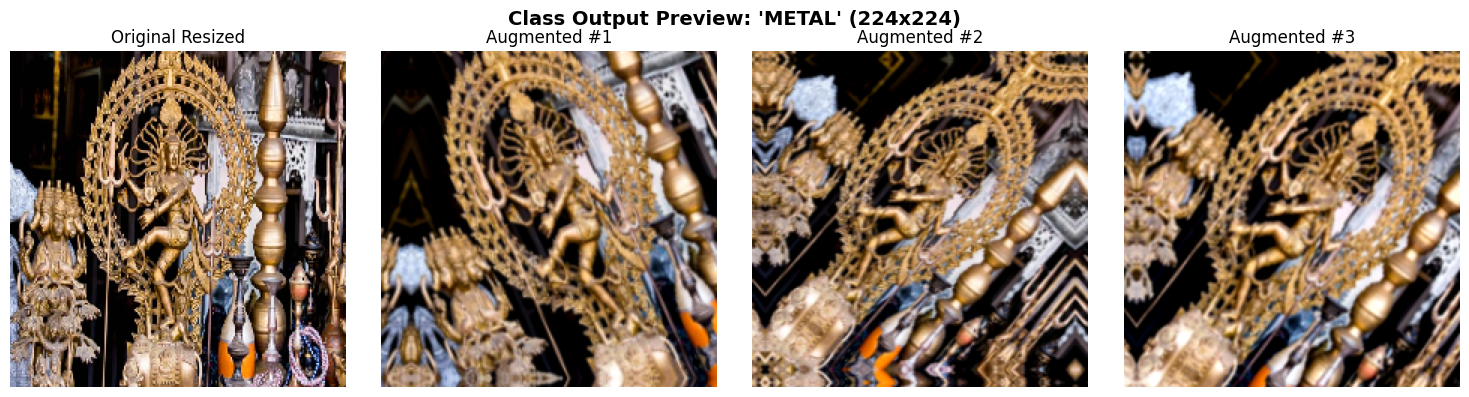

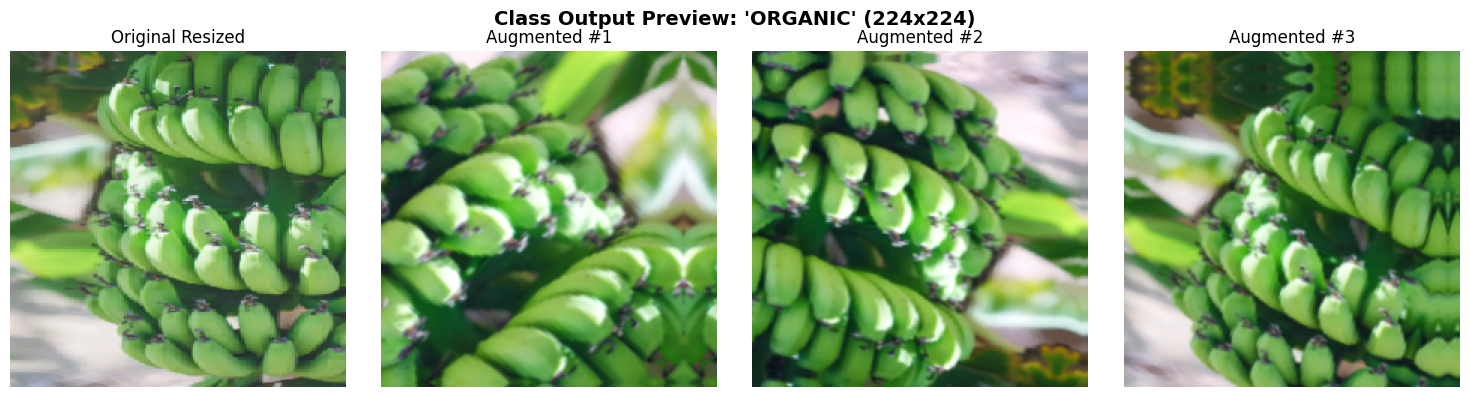

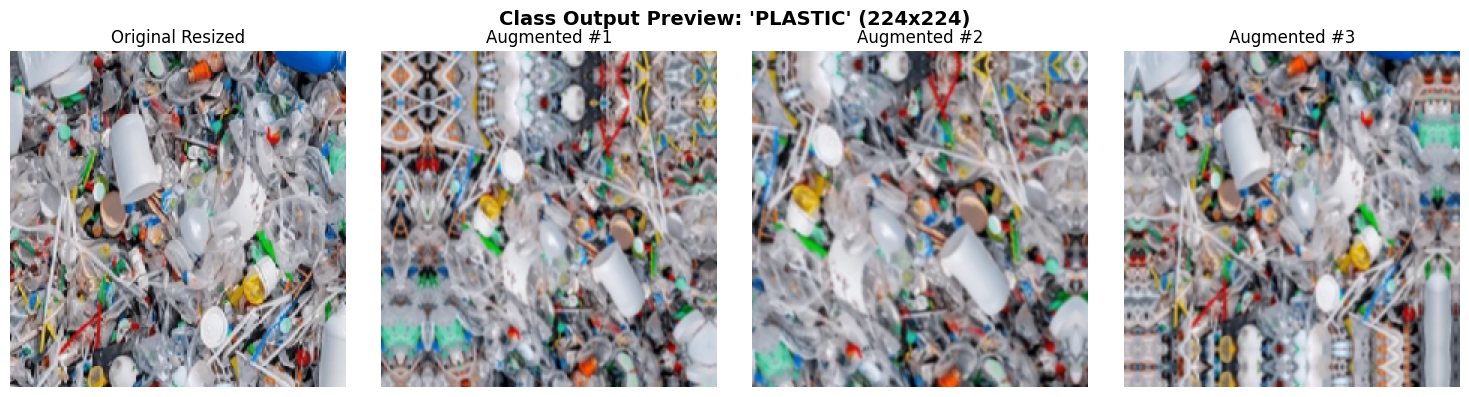

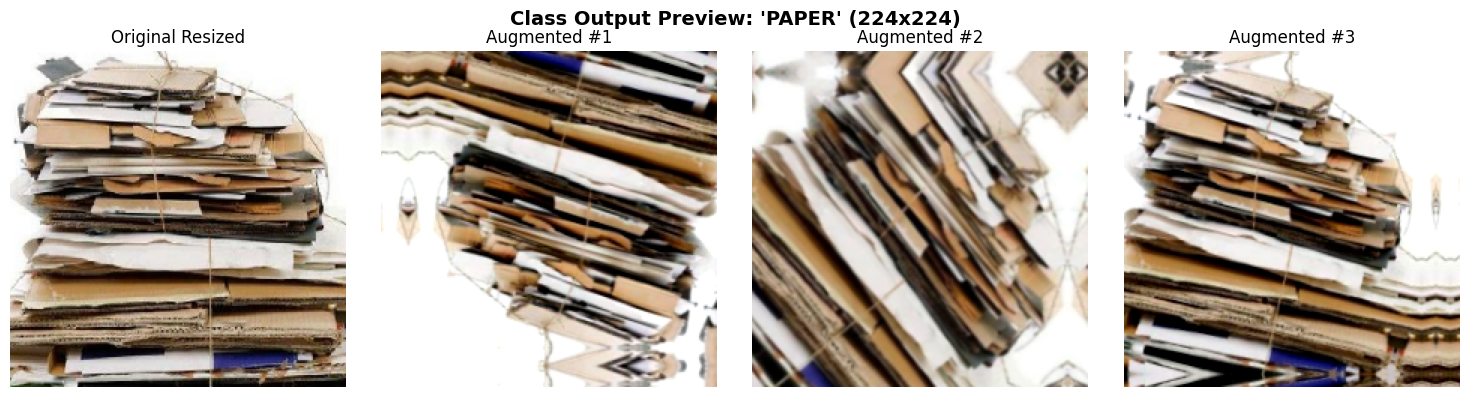

In [ ]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.utils import load_img, img_to_array, array_to_img
from google.colab import files

# ==========================================
# 1. UPLOAD & UNZIP DATASET
# ==========================================
if not os.path.exists('/content/dataset_raw'):
    print("📁 Please upload your dataset.zip file:")
    uploaded = files.upload()
    for filename in uploaded.keys():
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall('/content/dataset_raw')
    print("✅ Extraction complete!\n")

base_dir = '/content/dataset_raw/dataset' if os.path.exists('/content/dataset_raw/dataset') else '/content/dataset_raw'
output_dir = '/content/dataset_augmented'

# ==========================================
# 2. DEFINE AUGMENTATION PIPELINE
# ==========================================
IMG_SIZE = (224, 224)
AUGMENTATIONS_PER_IMAGE = 3

augmentation_pipeline = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.2)
])

# ==========================================
# 3. PROCESS, RESIZE, SAVE & COLLECT SAMPLE
# ==========================================
categories = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]

total_original = 0
total_generated = 0
sample_visualizations = [] # Stores images for inline display

print("⚙️ Resizing images and generating augmentations...\n")

for category in categories:
    input_class_dir = os.path.join(base_dir, category)
    output_class_dir = os.path.join(output_dir, category)
    os.makedirs(output_class_dir, exist_ok=True)

    image_files = [f for f in os.listdir(input_class_dir) if f.lower().endswith(('png', 'jpg', 'jpeg', 'webp'))]

    for idx, filename in enumerate(image_files):
        img_path = os.path.join(input_class_dir, filename)

        try:
            # Load and RESIZE original image to (224, 224)
            img = load_img(img_path, target_size=IMG_SIZE)
            img_array = img_to_array(img)

            # Save resized original image
            base_name, ext = os.path.splitext(filename)
            orig_save_path = os.path.join(output_class_dir, f"{base_name}_resized.jpg")
            img.save(orig_save_path)
            total_original += 1

            # Collect sample images for display (first image of each class)
            current_samples = [("Original Resized", img)]

            # Generate AUGMENTED images
            img_tensor = tf.expand_dims(img_array, 0)

            for i in range(AUGMENTATIONS_PER_IMAGE):
                aug_tensor = augmentation_pipeline(img_tensor, training=True)
                aug_array = tf.squeeze(aug_tensor, 0).numpy()
                aug_array = np.clip(aug_array, 0, 255).astype('uint8')
                aug_img = array_to_img(aug_array)

                aug_save_path = os.path.join(output_class_dir, f"{base_name}_aug_{i+1}.jpg")
                aug_img.save(aug_save_path)
                total_generated += 1

                if idx == 0:
                    current_samples.append((f"Augmented #{i+1}", aug_img))

            if idx == 0:
                sample_visualizations.append((category, current_samples))

        except Exception as e:
            print(f"⚠️ Skipping corrupt file {filename}: {e}")

# ==========================================
# 4. DISPLAY SUMMARY & VISUAL OUTPUT
# ==========================================
print("=" * 60)
print(f"🎉 PROCESSING COMPLETE!")
print(f"• Resized Originals Saved: {total_original}")
print(f"• Augmented Images Created: {total_generated}")
print(f"• Total Saved Dataset Size: {total_original + total_generated} images")
print(f"• Output Location:          {output_dir}")
print("=" * 60 + "\n")

# Display visual plot of outputs directly in notebook
for category, samples in sample_visualizations:
    fig, axes = plt.subplots(1, len(samples), figsize=(15, 4))
    fig.suptitle(f"Class Output Preview: '{category.upper()}' (224x224)", fontsize=14, fontweight='bold')

    for ax, (title, sample_img) in zip(axes, samples):
        ax.imshow(sample_img)
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


📂 Splitting dataset into Training (70%), Validation (15%), and Testing (15%)...


Copying files: 160 files [00:00, 7811.89 files/s]

Found 140 files belonging to 4 classes.
Found 28 files belonging to 4 classes.
Found 32 files belonging to 4 classes.

✅ Data Segregation Complete! Identified Classes (4): ['Metal', 'Paper', 'Plastic', 'organic']

--- Model Architecture Summary ---


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Normalization (Rescaling) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1_32Filters (Conv2D)        │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool1 (MaxPooling2D)         │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2_64Filters (Conv2D)        │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool2 (MaxPooling2D)         │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3_128Filters (Conv2D)       │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool3 (MaxPooling2D)         │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten_Features (Flatten)      │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_0.5 (Dropout)           │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_Hidden_128 (Dense)        │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Class_Probabilities      │ (None, 4)              │           516 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)


🚀 Starting Model Training for 20 Epochs...

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.2429 - loss: 2.5334 - val_accuracy: 0.2500 - val_loss: 1.4118
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.2500 - loss: 1.4049 - val_accuracy: 0.2500 - val_loss: 1.3792
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.2286 - loss: 1.3959 - val_accuracy: 0.4286 - val_loss: 1.3673
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.4357 - loss: 1.3701 - val_accuracy: 0.2857 - val_loss: 1.3797
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.3071 - loss: 1.3624 - val_accuracy: 0.2857 - val_loss: 1.3074
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.4071 - loss: 1.2863 - val_accuracy: 0.6429 - val_loss: 1.2843
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.4214 - loss: 1.2838 - val_accuracy: 0.2857 - val_loss: 1.1896
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5500 - loss: 1.161

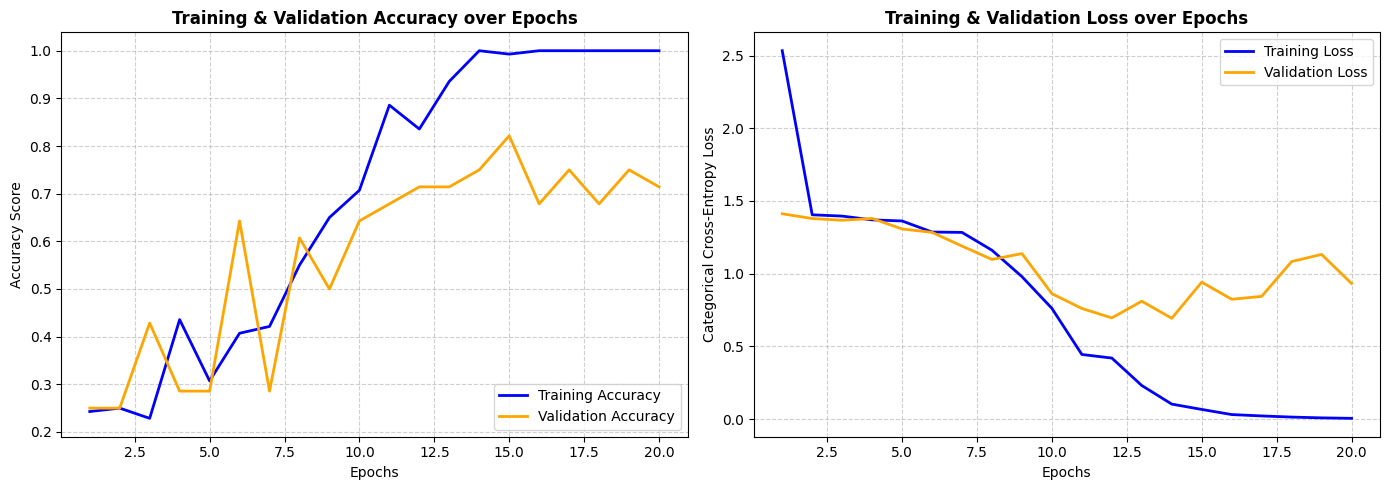


📊 Evaluating model on the unseen Test Dataset...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.8438 - loss: 0.6894

🎯 Final Test Set Accuracy: 84.38%
📉 Final Test Set Loss:     0.6894

📌 DATASET & MODELING CHALLENGES FACED & ADDRESSED:

1. Challenge: High Risk of Overfitting Due to Small Dataset Size
   - Impact: Deep networks easily memorize small photograph collections (20-30 images/class),
     leading to high training accuracy but poor real-world generalization.
   - Mitigation: Applied random data augmentations (flips, rotations, zooms, translation,
     contrast tweaks) and added a 50% Dropout layer in the classifier head.

2. Challenge: Visual Variance in Backgrounds and Lighting
   - Impact: Campus waste captured across different tables, floors, and daylight conditions
     caused noisy feature maps.
   - Mitigation: Normalized all input images using Rescaling(1./255) and resized all photos
     to a standard 224x224 RGB tensor format before feature extraction.



In [ ]:
# ==========================================
# CONTINUATION CODE
# ==========================================

# Install split-folders for splitting data into train/val/test
!pip install split-folders -q

import splitfolders
from tensorflow.keras import models

# ==========================================
# 5. SPLIT DATASET (70% Train, 15% Val, 15% Test)
# ==========================================
split_dir = '/content/dataset_split'

print("\n📂 Splitting dataset into Training (70%), Validation (15%), and Testing (15%)...")
splitfolders.ratio(
    output_dir,
    output=split_dir,
    seed=42,
    ratio=(0.7, 0.15, 0.15)
)

BATCH_SIZE = 32

# Load subsets into TensorFlow datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(split_dir, 'train'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(split_dir, 'val'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(split_dir, 'test'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"\n✅ Data Segregation Complete! Identified Classes ({num_classes}): {class_names}")

# Optimize data loading pipeline performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)


# ==========================================
# 6. DESIGN THE DEEP NEURAL NETWORK (DNN/CNN)
# ==========================================
"""
ARCHITECTURE EXPLANATION:
-------------------------
1. INPUT LAYER:
   - Rescaling Layer: Accepts image tensors of shape (224, 224, 3) representing 224x224 RGB pixels.
     Normalizes pixel intensities from [0, 255] to [0, 1] for stable gradient descent.

2. HIDDEN LAYERS & ACTIVATION FUNCTIONS:
   - Conv2D Layers (Feature Extractors): Uses 3 consecutive convolutional blocks (32, 64, 128 filters)
     with 3x3 kernels to learn hierarchical visual features like edges, textures, and shape boundaries.
   - ReLU Activation (Rectified Linear Unit): Applied after each convolution and dense layer to introduce
     non-linearity, enabling the network to learn complex non-linear waste features.
   - MaxPooling2D Layers: Reduces spatial dimensions (height x width) by half, reducing computational
     load and making visual feature detection invariant to small spatial shifts.
   - Flatten Layer: Converts 2D feature maps into a 1D feature vector.
   - Dense Layer (128 units): Fully connected layer that synthesizes abstract feature combinations.
   - Dropout Layer (rate = 0.5): Randomly turns off 50% of neurons during training to prevent
     overfitting and reliance on specific nodes.

3. OUTPUT LAYER:
   - Dense Layer (4 units): Softmax activation function outputs a multi-class probability distribution
     summing to 1.0 across the classes: Paper, Plastic, Metal, and Organic.
"""

model = models.Sequential([
    # Input Layer & Rescaling
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(1./255, name="Input_Normalization"),

    # Hidden Layer Block 1
    layers.Conv2D(32, (3, 3), activation='relu', name="Conv1_32Filters"),
    layers.MaxPooling2D((2, 2), name="MaxPool1"),

    # Hidden Layer Block 2
    layers.Conv2D(64, (3, 3), activation='relu', name="Conv2_64Filters"),
    layers.MaxPooling2D((2, 2), name="MaxPool2"),

    # Hidden Layer Block 3
    layers.Conv2D(128, (3, 3), activation='relu', name="Conv3_128Filters"),
    layers.MaxPooling2D((2, 2), name="MaxPool3"),

    # Fully-Connected Dense Hidden Layers
    layers.Flatten(name="Flatten_Features"),
    layers.Dropout(0.5, name="Dropout_0.5"),
    layers.Dense(128, activation='relu', name="Dense_Hidden_128"),

    # Output Layer
    layers.Dense(num_classes, activation='softmax', name="Output_Class_Probabilities")
])

print("\n--- Model Architecture Summary ---")
model.summary()


# ==========================================
# 7. TRAINING AND EVALUATION CONFIGURATION
# ==========================================
"""
OPTIMIZER & LOSS FUNCTION:
--------------------------
- Optimizer: Adam (Adaptive Moment Estimation) - Uses adaptive learning rates for fast,
  stable convergence without manual learning rate tuning.
- Loss Function: Categorical Cross-Entropy - Measures the difference between target one-hot
  encoded labels and predicted probability distributions for multi-class classification.

MONITORING METRICS:
-------------------
- Accuracy & Loss Curves: Epoch-by-epoch loss and accuracy are calculated on both Training
  and Validation sets to monitor convergence and detect overfitting in real-time.
"""

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
EPOCHS = 20
print(f"\n🚀 Starting Model Training for {EPOCHS} Epochs...\n")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# ==========================================
# 8. VISUALIZE TRAINING PERFORMANCE & METRICS
# ==========================================
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Training & Validation Accuracy over Epochs', fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy Score')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', linewidth=2)
plt.title('Training & Validation Loss over Epochs', fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Categorical Cross-Entropy Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Evaluate on unseen Test Set
print("\n📊 Evaluating model on the unseen Test Dataset...")
test_loss, test_acc = model.evaluate(test_ds)
print(f"\n🎯 Final Test Set Accuracy: {test_acc * 100:.2f}%")
print(f"📉 Final Test Set Loss:     {test_loss:.4f}")


# ==========================================
# 9. CHALLENGES & MITIGATIONS
# ==========================================
print("\n" + "="*60)
print("📌 DATASET & MODELING CHALLENGES FACED & ADDRESSED:")
print("="*60)
print("""
1. Challenge: High Risk of Overfitting Due to Small Dataset Size
   - Impact: Deep networks easily memorize small photograph collections (20-30 images/class),
     leading to high training accuracy but poor real-world generalization.
   - Mitigation: Applied random data augmentations (flips, rotations, zooms, translation,
     contrast tweaks) and added a 50% Dropout layer in the classifier head.

2. Challenge: Visual Variance in Backgrounds and Lighting
   - Impact: Campus waste captured across different tables, floors, and daylight conditions
     caused noisy feature maps.
   - Mitigation: Normalized all input images using Rescaling(1./255) and resized all photos
     to a standard 224x224 RGB tensor format before feature extraction.
""")